In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import (
    TrueRejection,
    FalseRejection,
    Rejection,
    RelativeFrobeniusNorm,
    ComputeAll,
    ProcrustesDistance
)

from src.helper_functions._metrics_helper import rv_coefficient, rv_coefficient_adjusted, cvm_stat_multivariate

from src.methods import (
    PermutationTest,
    RVPermutationTest,
    FitIndependent,
    LLKRatioTest,
    DiffusionCorrelation,
    CanonicalCorrelationTest,
    QAP
)
from src.solvers.binary_network import MLE_logistic
from src.solvers.MaMa_uuuuu import pgd_fit_wrapper, pgd_fit
from src.solvers.weighted_network import MLE_gaussian, ASE
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
from src.helper_functions.plot_functions import plot_grid, plot_with_bands
import scipy.stats as stats
from src.helper_functions.plot_functions import visualise_latent
from functools import partial

import numpy as np
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

from src.helper_functions.simulation_functions import run_scenario, run_scenario_wrapper

In [2]:
def run_simulation_parallel(
    nsim, factorial_design, metrics, method_params=None, rng=None, n_jobs=None
):
    if rng is None:
        rng = np.random.default_rng()

    if not isinstance(factorial_design, list):
        raise ValueError("factorial_design must be a list of tuples")

    if n_jobs is None:
        n_jobs = cpu_count()
        
    # Create all scenario arguments upfront (flattened structure)
    all_scenarios = [
        (args, metrics, method_params) for i in range(nsim) for args in factorial_design
    ]

    
    total_scenarios = len(all_scenarios)
    
    child_seeds = rng.spawn(total_scenarios)
    
    all_scenarios_seed = [
        (*scenario, seed) for scenario, seed in zip(all_scenarios, child_seeds)
    ]
    
    # Shuffle scenarios for better parallelisation
    rng.shuffle(all_scenarios_seed)

    # Better chunk size: balance between overhead and load distribution
    chunk_size = max(1, total_scenarios // (n_jobs * 32))

    results = []
    print(run_scenario_wrapper)
    with Pool(processes=n_jobs) as pool:
        with tqdm(total=total_scenarios, desc="Running scenarios") as pbar:
            # Use imap_unordered for better performance (order doesn't matter)
            for result in pool.imap_unordered(
                run_scenario_wrapper, all_scenarios_seed, chunksize=chunk_size
            ):
                results.append(result)
                pbar.update(1)

    return results

In [3]:
def run_simulation(
    nsim,
    factorial_design,
    metrics,
    method_params=None,
    parallel=False,
    rng=None,
    n_jobs=None,
):
    """Run a simulation study.

    Parameters
    ----------
    nsim : _type_
        _description_
    factorial_design : _type_
        _description_
    metrics : _type_
        _description_
    method_params : _type_, optional
        _description_, by default None
    parallel : bool, optional
        _description_, by default False
    rng : _type_, optional
        _description_, by default None
    n_jobs : _type_, optional
        _description_, by default None
    data : dict, optional
       Dictionary containing keys 'estimate_latent_x', 'estimate_latent_y', 
       'true_latent_x', and 'true_latent_y'.

    Returns
    -------
    _type_
        _description_
    """
    if parallel:
        return run_simulation_parallel(
            nsim=nsim,
            factorial_design=factorial_design,
            metrics=metrics,
            method_params=method_params,
            rng=rng,
            n_jobs=n_jobs,
        )

    if rng is None:
        rng = np.random.default_rng()

    results = []
    
    
    # for i in range(nsim):
    #     print(f"Simulation {i + 1} of {nsim}")
    #     for args in tqdm(factorial_design, desc="Running scenarios"):
    #         scenario_out = run_scenario(metrics, args, method_params=method_params)
    #         results.append(scenario_out)
    
    for i in range(nsim):
        sim_seeds = rng.spawn(len(factorial_design))

        for args, seed in zip(tqdm(factorial_design), sim_seeds):
            scenario_out = run_scenario(metrics, args, method_params=method_params, seed=seed)
            results.append(scenario_out)

    return results

In [4]:
import h5py

def load_hdf5(path):
    def read_obj(obj):

        # dataset
        if isinstance(obj, h5py.Dataset):
            return obj[()]

        # group
        if isinstance(obj, h5py.Group):
            out = {}

            # put attributes directly as keys
            out.update({k: v for k, v in obj.attrs.items()})

            for key, item in obj.items():
                out[key] = read_obj(item)

            return out

    with h5py.File(path, "r") as f:
        return {k: read_obj(v) for k, v in f.items()}

data = load_hdf5('data.h5')

In [33]:
nsim = 1
alpha = [0.05]

method = [
    partial(RVPermutationTest, permutation_type="latent"),
    LLKRatioTest,
    DiffusionCorrelation,
]

npermutations = [100]
metrics = [ComputeAll()]
approximation = ["F-distr"]

rng = np.random.default_rng(1)    

param_names = [
    "method",
    "alpha",
    "approximation",
    "npermutations"
]

param_values = product(method, alpha, approximation, npermutations)

temp = [dict(zip(param_names, v)) for v in param_values]

factorial_design = []

i = 0
for x in data:
    for d in temp:
        attrs = {k: v for k, v in data[x].items() if not isinstance(v, np.ndarray)}
        datasets = {k: v for k, v in data[x].items() if isinstance(v, np.ndarray)}

        factorial_design.append({
            **attrs,
            **d,
            "data": datasets
        })
    i +=1
    
    if i > 100:
        break

In [34]:
out = run_simulation(
    nsim=nsim,
    metrics=metrics,
    factorial_design=factorial_design,
    rng=rng,
    parallel=True,
)

out = pd.DataFrame(out)

<function run_scenario_wrapper at 0x145b1d580>


Running scenarios: 100%|██████████| 303/303 [03:23<00:00,  1.49it/s]


In [35]:
out["n"] = out["args"].apply(lambda x: x["n"])
out["k"] = out["args"].apply(lambda x: x["k"])
out["edge_var"] = out["args"].apply(lambda x: x.get("edge_var", "NA"))
out["approximation"] = out["args"].apply(lambda x: x.get("approximation", "NA"))
out["dgp"] = out["args"].apply(lambda x: x["dgp_name"])
out["solver"] = out["args"].apply(lambda x: x["solver"])
out['rho'] = out["args"].apply(lambda x: x.get("rho", "NA"))

out["method"] = out["args"].apply(lambda x: x.get("method_name", "NA"))

out["marginals"] = out["args"].apply(lambda x: x.get("marginals", "NA"))

In [36]:
# out["FalseRejection"] = out["ComputeAll"].apply(lambda x: x["FalseRejection"])
# out["TrueRejection"] = out["ComputeAll"].apply(lambda x: x["TrueRejection"])
# out["Rejection"] = out["ComputeAll"].apply(lambda x: x["Rejection"])
out['RelativeFrobeniusNorm_x'] = out["ComputeAll"].apply(lambda x: x["RelativeFrobeniusNorm_x"])
out['ProcrustesDistance_x'] = out["ComputeAll"].apply(lambda x: x["ProcrustesDistance_x"])
out['RelativeFrobeniusNorm_z'] = out["ComputeAll"].apply(lambda x: x["RelativeFrobeniusNorm_z"])
out['ProcrustesDistance_z'] = out["ComputeAll"].apply(lambda x: x["ProcrustesDistance_z"])

In [37]:
results_gaussian = out[out["dgp"] == "GaussianNetwork"]
results_bernoulli = out[out["dgp"] == "BernoulliNetwork"]

results_null_gaussian = results_gaussian[results_gaussian["rho"] == 0]
results_null_bernoulli = results_bernoulli[results_bernoulli["rho"] == 0]

results_null_gaussian_rv = results_null_gaussian[
    results_null_gaussian["method"] == "RVPermutationTest"
]
results_null_gaussian_llk = results_null_gaussian[
    results_null_gaussian["method"] == "LLKRatioTest"
]

results_05_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.5)
]

results_02_gaussian = out[
    (out['dgp'] == "GaussianNetwork") & (out['rho'] == 0.2)
]

In [38]:
# agg_gaussian_x = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_gaussian_z = aggregate_results(
#     results_gaussian,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_x = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_x",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )
# agg_bernoulli_z = aggregate_results(
#     results_bernoulli,
#     y_axis="RelativeFrobeniusNorm_z",
#     x_axis="n",
#     factors=["edge_var", "k", "solver"],
# )

# agg_gaussian_null = aggregate_results(
#     results_null_gaussian,
#     y_axis="FalseRejection",
#     x_axis="n",
#     factors=["marginals", "solver", "method"],
# )

agg_05_gaussian = aggregate_results(
    results_05_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

agg_bernoulli_null = aggregate_results(
    results_null_bernoulli,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

agg_02_gaussian = aggregate_results(
    results_02_gaussian,
    y_axis="RelativeFrobeniusNorm_x",
    x_axis="n",
    factors=["marginals", "solver", "method"],
)

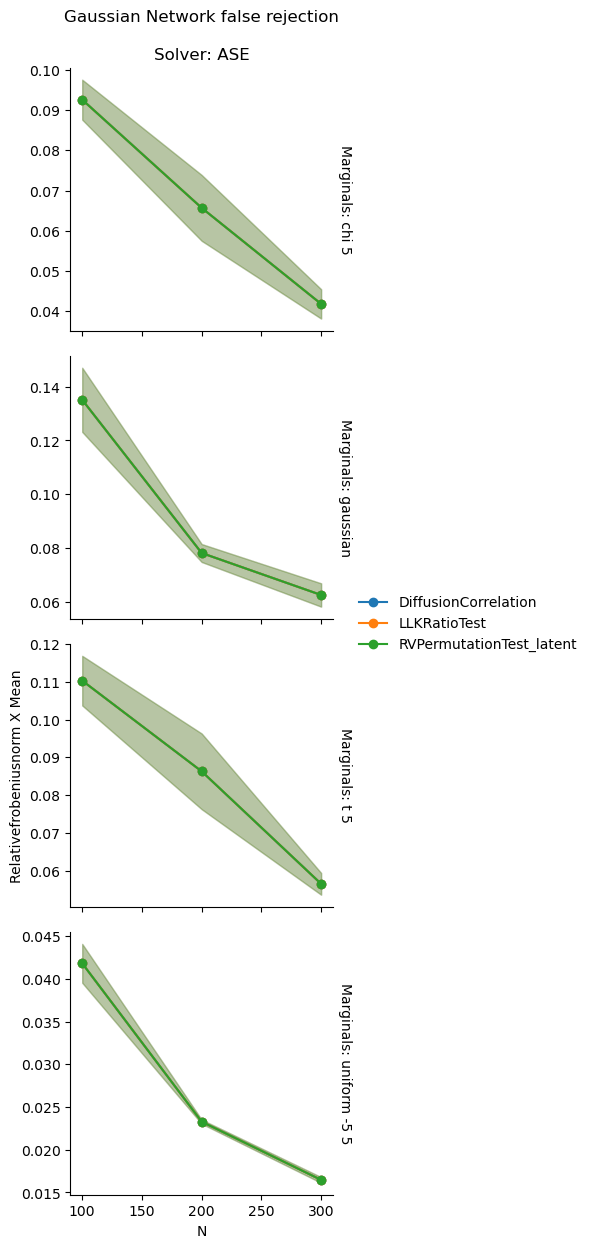

In [39]:
plot_grid(
    grouped_stats=agg_02_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["method", "solver", "marginals"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
    title="Gaussian Network false rejection",
)